# 02 - Escalamiento sismico hacia spectrum target

Compara escalamiento lineal, ajuste en dominio de Fourier y matching espectral con wavelets.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

import matplotlib.pyplot as plt
import pandas as pd
import signalprocessor as sp
from signalprocessor.plotting import plot_scaling_summary, plot_arias_comparison

plt.rcParams['figure.dpi'] = 120

In [2]:
motion = sp.read_motion_csv(ROOT / 'examples/data/motion/LIMANS.csv', acceleration_unit='g', record_id='LIMANS')
target = sp.read_target_spectrum_csv(ROOT / 'examples/data/target_response_spectrum/EPU_475.csv')
cfg = sp.load_json(ROOT / 'examples/config/scaling.json')

target_df = pd.DataFrame({'period_s': target.periods_s, 'target_Sa_g': target.sa_g})
target_df.head()

,period_s,target_Sa_g
0,0.010,0.307
1,0.020,0.323
2,0.030,0.384
3,0.050,0.539
4,0.075,0.712


## Comparacion de metodos

`linear` preserva exactamente la forma temporal normalizada. `frequency` es muy rapido y modifica amplitudes de Fourier. `wavelet` agrega ondas localizadas en el tiempo y controla Arias/desplazamiento despues del ajuste.

In [3]:
comparison = sp.compare_scaling_methods(
    motion,
    target.periods_s,
    target.sa_g,
    methods=('linear', 'frequency', 'wavelet'),
    period_range_s=(0.05, 2.0),
    config={
        'spectral_matching': {
            'mismatch_tolerance': 0.08,
            'max_iterations': 8,
            'wavelets': {'max_number_of_waves': 6},
        }
    },
)
comparison.summary

,method,record_id,max_abs_relative_error,mean_abs_relative_error,rms_log_error,mean_log_bias,runtime_s,PGA_ratio,PGV_ratio,PGD_ratio,arias_ratio,D_5_95_ratio,CAV_ratio,scale_factor,pre_scale_factor,blend_exponent,iterations,tolerance
0,frequency,LIMANS,0.543860,0.186023,0.296119,-1.109244e-01,0.176393,1.011838,1.022246,1.372786,1.266680,0.988641,1.126584,NaN,1.240849,0.65,NaN,NaN
1,wavelet,LIMANS,1.094189,0.255073,0.316651,1.081947e-01,3.542514,1.263166,1.408522,1.375039,1.565031,0.998124,1.243666,NaN,1.240849,NaN,8.0,0.08
2,linear,LIMANS,1.094190,0.299960,0.385296,-3.309319e-16,0.114423,1.240849,1.240849,1.240849,1.539707,1.000000,1.240849,1.240849,NaN,NaN,NaN,NaN


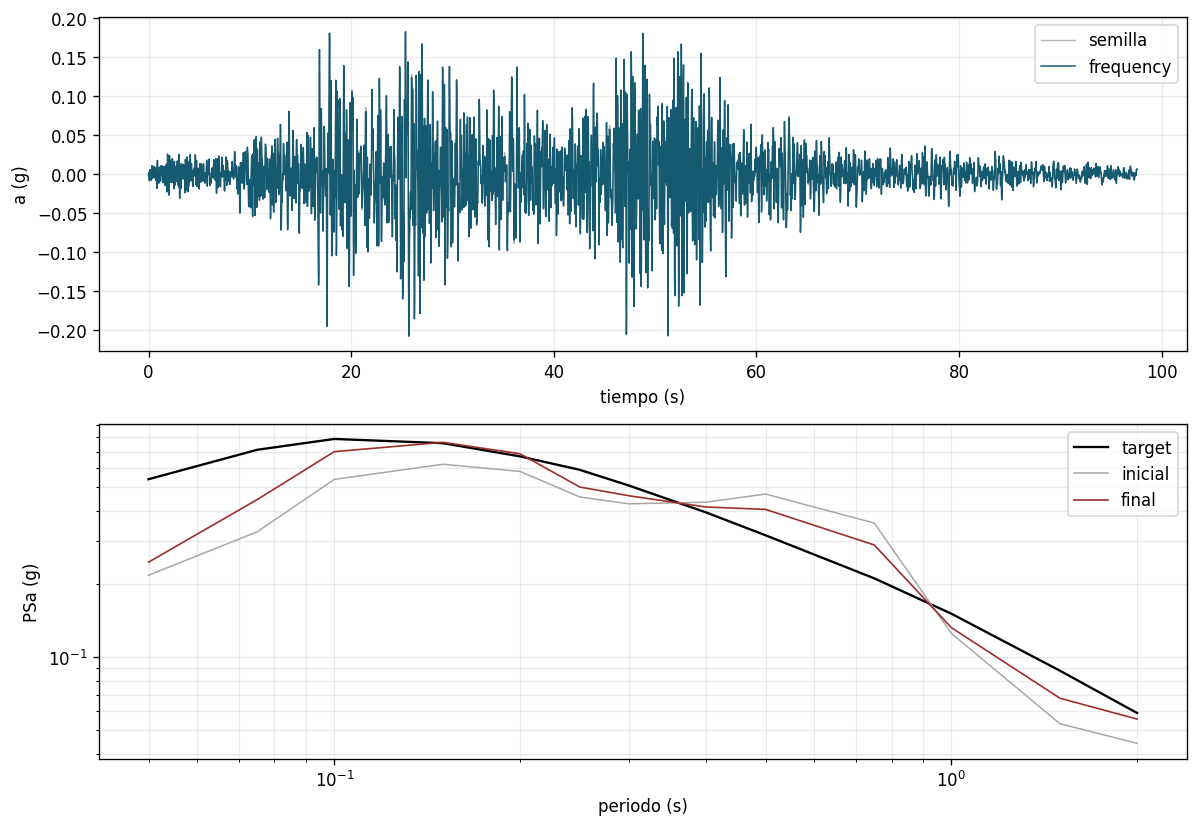

In [4]:
best_method = comparison.summary.iloc[0]['method']
best = comparison.results[best_method]
plot_scaling_summary(best);

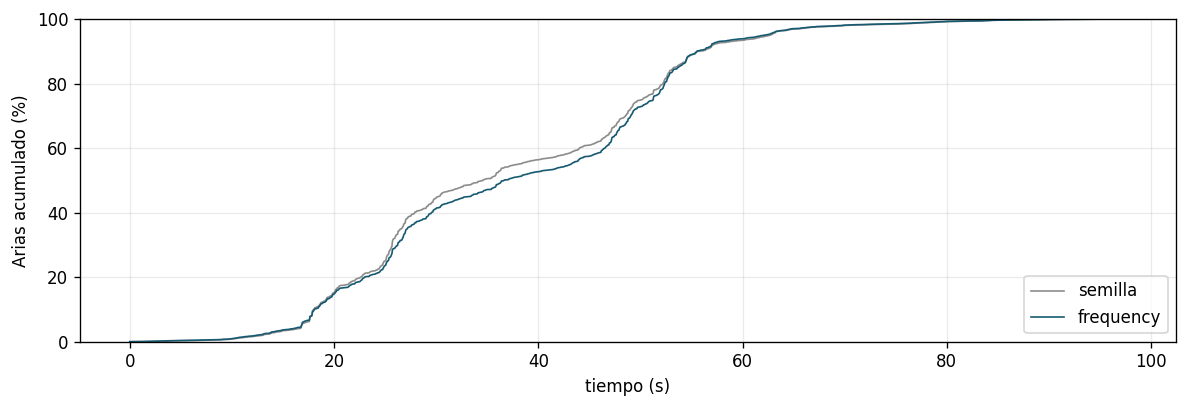

In [5]:
plot_arias_comparison(best);

## Detalle de convergencia wavelet

In [6]:
wavelet = comparison.results['wavelet']
pd.DataFrame(wavelet.details['convergence_history'])

,iteration,max_abs_relative_error,rms_log_error
0,1,1.094190,0.385296
1,2,1.094067,0.384302
2,3,1.094067,0.375397
3,4,1.094067,0.367453
4,5,1.094067,0.357773
5,6,1.094067,0.343157
6,7,1.094067,0.329429
7,8,1.094067,0.321855


## Exportar resultados

In [7]:
out = ROOT / 'examples/output/scaling'
comparison.write_outputs(out)
out

WindowsPath('c:/Users/joel.alarcon/Desktop/_code/prismo/external/SignalProcessor/examples/output/scaling')